# Подготовка набора данных

Подготовка библиотек и отключение предупреждений

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Импорт библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_theme(style="ticks")

Подключение Google Drive к блокноту Google Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузка набора данных

Набор данных, используемый в лабораторных работах доступен по [ссылке](https://www.kaggle.com/datasets/mssmartypants/paris-housing-classification)

Поскольку работы выполнены в среде Google Colaboratory, путь до файла указывается относительно директории, к которой примонтирован Google диск

In [ ]:
ParisHousingClass_df = pd.read_csv('/content/drive/MyDrive/ParisHousingClass.csv')
ParisHousingClass_df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,category
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5,Basic
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5,Luxury
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1,Basic
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2,Basic
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0,Luxury


Разделение на матрицу признаков и зависимую переменную

In [ ]:
X = ParisHousingClass_df.drop(['price'], axis=1)
y = ParisHousingClass_df.price
print("Матрица признаков")
print(X.values)
print("Зависимая переменная")
print(y.values)

Матрица признаков
[[75523 3 0 ... 0 7 'Basic']
 [80771 39 1 ... 1 2 'Luxury']
 [55712 58 0 ... 1 9 'Basic']
 ...
 [83841 3 0 ... 1 9 'Basic']
 [59036 70 0 ... 1 4 'Basic']
 [1440 84 0 ... 1 6 'Basic']]
Зависимая переменная
[7559081.5 8085989.5 5574642.1 ... 8390030.5 5905107.   146708.4]


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer


categoricalColumns = ['category', 'numPrevOwners']
droppedColumns = ['cityCode']
leaveColumns = X.columns.difference(categoricalColumns)
leaveColumns = leaveColumns.difference(droppedColumns)

# Создаем список трансформеров
transformers = [
    ('text_encoder', OrdinalEncoder(), categoricalColumns),
    ('preprocessed', 'passthrough', leaveColumns)
]
# Создаем объект ColumnTransformer и передаем ему список трансформеров
data_preprocessor = ColumnTransformer(transformers)

# Линейная регрессия

Разделим выборку на тестовую и тренировочную и обучим предсказывать стоимость собственности с использованием линейного регрессора

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 17)
regression_pipeline = make_pipeline(data_preprocessor, LinearRegression())

In [ ]:
regression_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('text_encoder',
                                                  OrdinalEncoder(),
                                                  ['category',
                                                   'numPrevOwners']),
                                                 ('preprocessed', 'passthrough',
                                                  Index(['attic', 'basement', 'cityPartRange', 'floors', 'garage',
       'hasGuestRoom', 'hasPool', 'hasStorageRoom', 'hasStormProtector',
       'hasYard', 'isNewBuilt', 'made', 'numberOfRooms', 'squareMeters'],
      dtype='object'))])),
                ('linearregression', LinearRegression())])

## Предсказание и визуализация результатов

Предсказание результатов

In [ ]:
y_pred = regression_pipeline.predict(X_test)
print(y_pred)

[7368649.07268037 6113691.76919987 6787416.08398009 ... 4271800.55249771
 8531375.85334669 3508896.22838071]


Графическое представление зависимости цены от площади недвижимости

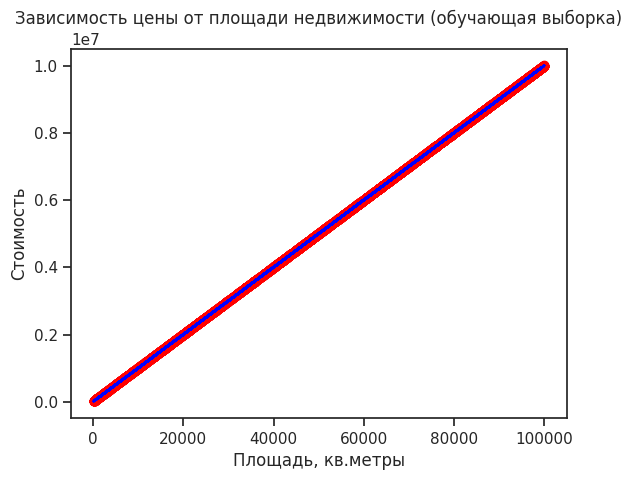

In [ ]:
plt.scatter(x=X_train['squareMeters'], y=y_train, color = 'red')
plt.plot(X_train['squareMeters'], regression_pipeline.predict(X_train), color = 'blue')
plt.title('Зависимость цены от площади недвижимости (обучающая выборка)')
plt.xlabel('Площадь, кв.метры')
plt.ylabel('Стоимость')
plt.show()

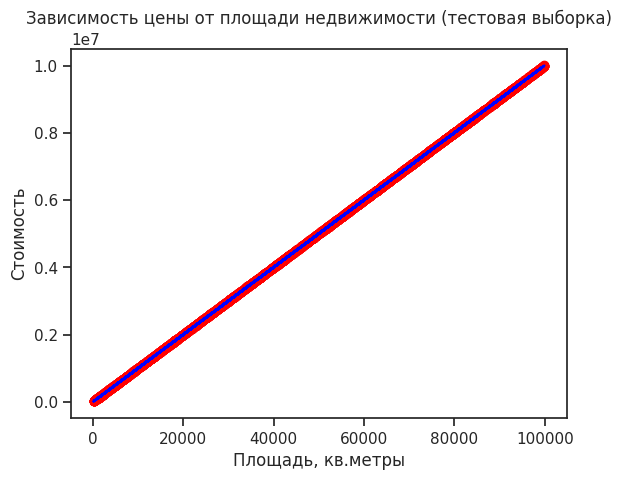

In [ ]:
plt.scatter(x=X_test['squareMeters'], y=y_test, color = 'red')
plt.plot(X_test['squareMeters'], regression_pipeline.predict(X_test), color = 'blue')
plt.title('Зависимость цены от площади недвижимости (тестовая выборка)')
plt.xlabel('Площадь, кв.метры')
plt.ylabel('Стоимость')
plt.show()

Найдем коэффициент детерминации, который поможет измерить степень соответсвия модели реальным данным

In [ ]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_pipeline.predict(X_test))
print(f'Оценка R^2 (коэффициент детерминации) на тестовой выборке: {score:.3f}')

Оценка R^2 (коэффициент детерминации) на тестовой выборке: 1.000


`R2 = 1`, что указывает на высокую степень соответсвия данных модели

Это означает, что модель линейной регрессии соответствует данным, на которых она построена